# ODIR-5K — Обучение модели (Google Colab)
**Дипломная работа:** Автоматизация диагностики офтальмологических заболеваний

### Перед запуском:
1. `Runtime` → `Change runtime type` → **T4 GPU**
2. Запускайте ячейки по порядку сверху вниз

## Шаг 1 — Проверка GPU

In [2]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA доступен:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('Память GPU:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    print('⚠️  GPU не найден — проверьте Runtime → Change runtime type → T4 GPU')

PyTorch: 2.10.0+cu128
CUDA доступен: True
GPU: Tesla T4
Память GPU: 15.6 GB


## Шаг 2 — Монтирование Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')
print('✅ Google Drive подключён')

Mounted at /content/drive
✅ Google Drive подключён


## Шаг 3 — Скачивание датасета с Kaggle

Нужен файл `kaggle.json` с вашими API-ключами.

**Как получить kaggle.json:**
1. Зайдите на kaggle.com → Profile → Settings
2. Раздел API → **Create New Token**
3. Скачается файл `kaggle.json`
4. Загрузите его в следующей ячейке

In [4]:
# Загружаем kaggle.json
from google.colab import files
print('Выберите файл kaggle.json ...')
uploaded = files.upload()

import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.replace('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print('✅ kaggle.json установлен')

Выберите файл kaggle.json ...


Saving kaggle.json to kaggle.json
✅ kaggle.json установлен


In [5]:
# Скачиваем датасет (~2 ГБ, займёт 2-5 минут)
!pip install -q kaggle
!kaggle datasets download -d andrewmvd/ocular-disease-recognition-odir5k -p /content/data --unzip
print('✅ Датасет скачан')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/ocular-disease-recognition-odir5k
License(s): other
100% 1.62G/1.62G [00:14<00:00, 119MB/s]

✅ Датасет скачан


In [6]:
# Проверяем структуру
import os
for root, dirs, files_list in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files_list[:5]:
            print(f'{indent}  {f}')

data/
  full_df.csv
  ODIR-5K/
    ODIR-5K/
      Training Images/
      Testing Images/
  preprocessed_images/
    455_left.jpg
    4049_right.jpg
    2653_right.jpg
    3048_right.jpg
    3450_right.jpg


## Шаг 4 — Установка библиотек

In [7]:
!pip install -q albumentations
import albumentations
print('albumentations:', albumentations.__version__)
print('✅ Все библиотеки готовы')

albumentations: 2.0.8
✅ Все библиотеки готовы


## Шаг 5 — Конфигурация путей

In [8]:
from pathlib import Path
import glob

# Автоматически находим папку с изображениями
data_root = Path('/content/data')

# Ищем папку Training Images
train_dirs = list(data_root.rglob('Training Images'))
if not train_dirs:
    train_dirs = list(data_root.rglob('Training*'))
TRAIN_IMG_DIR = train_dirs[0] if train_dirs else None
print('Train images:', TRAIN_IMG_DIR)

# Ищем full_df.csv
csv_files = list(data_root.rglob('full_df.csv'))
ANNOTATION_FILE = csv_files[0] if csv_files else None
print('Annotations:', ANNOTATION_FILE)

# Если full_df.csv нет — ищем любой CSV с метками
if not ANNOTATION_FILE:
    csv_files = list(data_root.rglob('*.csv'))
    print('Доступные CSV:', csv_files)

PROCESSED_DIR = Path('/content/processed')
MODELS_DIR    = Path('/content/models')
PROCESSED_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

# Проверяем
assert TRAIN_IMG_DIR and TRAIN_IMG_DIR.exists(), f'Папка со снимками не найдена!'
assert ANNOTATION_FILE and ANNOTATION_FILE.exists(), f'Файл аннотаций не найден!'
print('\n✅ Все пути найдены')

Train images: /content/data/ODIR-5K/ODIR-5K/Training Images
Annotations: /content/data/full_df.csv

✅ Все пути найдены


## Шаг 6 — Подготовка данных

In [9]:
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split

CLASSES     = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
CLASS_NAMES = {'N':'Normal','D':'Diabetes','G':'Glaucoma','C':'Cataract',
               'A':'AMD','H':'Hypertension','M':'Myopia','O':'Other'}
IMG_SIZE    = 224
BATCH_SIZE  = 32
RANDOM_SEED = 42
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
print('Device:', DEVICE)

Device: cuda


In [10]:
# Загрузка и подготовка аннотаций
df_raw = pd.read_csv(ANNOTATION_FILE)
df_raw.columns = [c.strip() for c in df_raw.columns]
df_raw.rename(columns={'Left-Fundus':'filename_left','Right-Fundus':'filename_right'}, inplace=True)
for cls in CLASSES:
    if cls in df_raw.columns:
        df_raw[cls] = df_raw[cls].astype(int)
print(f'Загружено {len(df_raw)} пациентов')
print('Колонки:', df_raw.columns.tolist())

Загружено 6392 пациентов
Колонки: ['ID', 'Patient Age', 'Patient Sex', 'filename_left', 'filename_right', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']


In [11]:
# Разворачиваем пары снимков
rows = []
for _, row in df_raw.iterrows():
    for side in ('left', 'right'):
        fname = row[f'filename_{side}']
        fpath = TRAIN_IMG_DIR / fname
        rows.append({
            'filepath': str(fpath),
            'filename': fname,
            'side': side,
            **{cls: row[cls] for cls in CLASSES if cls in row}
        })

df = pd.DataFrame(rows)
exists_mask = df['filepath'].apply(lambda p: Path(p).exists())
missing = (~exists_mask).sum()
print(f'Найдено снимков: {exists_mask.sum()} | Пропущено: {missing}')
df = df[exists_mask].reset_index(drop=True)

# Распределение классов
print('\nРаспределение по классам:')
for cls in CLASSES:
    cnt = df[cls].sum()
    print(f'  {CLASS_NAMES[cls]:<15}: {cnt:>5} ({cnt/len(df)*100:.1f}%)')

Найдено снимков: 12784 | Пропущено: 0

Распределение по классам:
  Normal         :  4202 (32.9%)
  Diabetes       :  4246 (33.2%)
  Glaucoma       :   794 (6.2%)
  Cataract       :   804 (6.3%)
  AMD            :   638 (5.0%)
  Hypertension   :   406 (3.2%)
  Myopia         :   612 (4.8%)
  Other          :  3176 (24.8%)


In [12]:
# Стратифицированное разбиение 70/15/15
df['_strat'] = df[CLASSES].apply(
    lambda row: int(np.argmax(row.values)) if row.values.sum() > 0 else -1, axis=1
)
train_val, test_df = train_test_split(
    df, test_size=0.15, random_state=RANDOM_SEED, stratify=df['_strat'])
train_df, val_df = train_test_split(
    train_val, test_size=0.15/0.85, random_state=RANDOM_SEED, stratify=train_val['_strat'])

train_df = train_df.drop(columns=['_strat']).reset_index(drop=True)
val_df   = val_df.drop(columns=['_strat']).reset_index(drop=True)
test_df  = test_df.drop(columns=['_strat']).reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_df.to_csv(PROCESSED_DIR / 'train.csv', index=False)
val_df.to_csv(PROCESSED_DIR / 'val.csv', index=False)
test_df.to_csv(PROCESSED_DIR / 'test.csv', index=False)

# Веса классов
pos_counts = train_df[CLASSES].sum(axis=0).values
neg_counts = len(train_df) - pos_counts
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-8), dtype=torch.float32)
print('\nPos weights:', {c: round(w, 2) for c, w in zip(CLASSES, pos_weight.tolist())})

Train: 8948 | Val: 1918 | Test: 1918

Pos weights: {'N': 2.04, 'D': 2.01, 'G': 15.12, 'C': 14.98, 'A': 19.02, 'H': 30.29, 'M': 20.05, 'O': 3.04}


## Шаг 7 — Dataset и аугментации

In [13]:
def get_train_transforms():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.3),
        A.Rotate(limit=30, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.3),
        A.GaussNoise(var_limit=(10, 50), p=0.2),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2(),
    ])

def get_val_transforms():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
        ToTensorV2(),
    ])

class ODIRDataset(Dataset):
    def __init__(self, df, transforms):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.classes = [c for c in CLASSES if c in df.columns]

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            image = np.array(Image.open(row['filepath']).convert('RGB'))
        except Exception:
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        image_t = self.transforms(image=image)['image']
        labels  = torch.tensor(row[self.classes].values.astype(np.float32))
        return image_t, labels

train_dataset = ODIRDataset(train_df, get_train_transforms())
val_dataset   = ODIRDataset(val_df,   get_val_transforms())
test_dataset  = ODIRDataset(test_df,  get_val_transforms())

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Быстрая проверка
imgs, lbls = next(iter(train_loader))
print(f'Батч: images={imgs.shape}, labels={lbls.shape}')
print('✅ DataLoader готов')

/tmp/ipykernel_1772/1220294043.py:9: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(10, 50), p=0.2),


Батч: images=torch.Size([32, 3, 224, 224]), labels=torch.Size([32, 8])
✅ DataLoader готов


## Шаг 8 — Модель EfficientNet-B0

In [14]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import roc_auc_score, f1_score
import time

def build_model(num_classes=8):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

model = build_model().to(DEVICE)
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Параметров: {params:,}')
print(f'Модель на: {next(model.parameters()).device}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 96.9MB/s]


Параметров: 4,017,796
Модель на: cuda:0


## Шаг 9 — Обучение

In [15]:
def compute_metrics(all_labels, all_probs, threshold=0.5):
    all_preds = (all_probs >= threshold).astype(int)
    metrics = {}
    try:
        auc_list = []
        for i in range(len(CLASSES)):
            if all_labels[:, i].sum() > 0:
                auc_list.append(roc_auc_score(all_labels[:, i], all_probs[:, i]))
        metrics['auc_macro'] = round(float(np.mean(auc_list)), 4)
    except:
        metrics['auc_macro'] = 0.0
    metrics['f1_macro'] = round(float(f1_score(all_labels, all_preds, average='macro', zero_division=0)), 4)
    metrics['f1_micro'] = round(float(f1_score(all_labels, all_preds, average='micro', zero_division=0)), 4)
    return metrics

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, all_labels, all_probs = 0.0, [], []
    for images, labels in tqdm(loader, desc='train', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        all_probs.append(torch.sigmoid(model(images)).detach().cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return total_loss / len(loader.dataset), compute_metrics(np.vstack(all_labels), np.vstack(all_probs))

@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []
    for images, labels in tqdm(loader, desc='val', leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * images.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    return total_loss / len(loader.dataset), compute_metrics(np.vstack(all_labels), np.vstack(all_probs))

In [16]:
NUM_EPOCHS    = 20
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
LR_PATIENCE   = 3
STOP_PATIENCE = 7

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=LR_PATIENCE)

history = {'train_loss':[],'val_loss':[],'train_auc':[],'val_auc':[],'train_f1':[],'val_f1':[]}
best_val_auc, best_epoch, no_improve = 0.0, 0, 0
best_model_path = MODELS_DIR / 'best_efficientnet_b0.pth'

print(f'Обучение на {DEVICE} | {NUM_EPOCHS} эпох | batch={BATCH_SIZE}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    train_loss, train_m = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_m   = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_m['auc_macro'])
    history['val_auc'].append(val_m['auc_macro'])
    history['train_f1'].append(train_m['f1_macro'])
    history['val_f1'].append(val_m['f1_macro'])

    print(f"Epoch {epoch:>2}/{NUM_EPOCHS} | "
          f"loss={train_loss:.4f}/{val_loss:.4f} | "
          f"auc={train_m['auc_macro']:.4f}/{val_m['auc_macro']:.4f} | "
          f"f1={train_m['f1_macro']:.4f}/{val_m['f1_macro']:.4f} | "
          f"{time.time()-t0:.0f}s")

    if val_m['auc_macro'] > best_val_auc:
        best_val_auc = val_m['auc_macro']
        best_epoch   = epoch
        no_improve   = 0
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'val_auc': best_val_auc, 'classes': CLASSES, 'img_size': IMG_SIZE,
        }, best_model_path)
        print(f'  ✅ Best AUC: {best_val_auc:.4f} → сохранено')
    else:
        no_improve += 1
        if no_improve >= STOP_PATIENCE:
            print(f'\nEarly stopping на эпохе {epoch} (лучшая: {best_epoch})')
            break

print(f'\n✅ Готово! Лучший AUC: {best_val_auc:.4f} (эпоха {best_epoch})')

Обучение на cuda | 20 эпох | batch=32



train:   0%|          | 0/280 [00:00<?, ?it/s]

val:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch  1/20 | loss=1.0150/0.8102 | auc=0.7167/0.8042 | f1=0.2885/0.4089 | 398s
  ✅ Best AUC: 0.8042 → сохранено


train:   0%|          | 0/280 [00:00<?, ?it/s]

...

val:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 19/20 | loss=0.5042/0.5594 | auc=0.9160/0.9179 | f1=0.5654/0.6669 | 382s
  ✅ Best AUC: 0.9179 → сохранено


train:   0%|          | 0/280 [00:00<?, ?it/s]

val:   0%|          | 0/60 [00:00<?, ?it/s]

Epoch 20/20 | loss=0.4968/0.5396 | auc=0.9203/0.9217 | f1=0.5648/0.6966 | 380s
  ✅ Best AUC: 0.9217 → сохранено

✅ Готово! Лучший AUC: 0.9217 (эпоха 20)


In [24]:
from sklearn.metrics import roc_auc_score, f1_score
import numpy as np

# Собираем предсказания на val-выборке
model.eval()
all_probs, all_labels = [], []

with torch.no_grad():
    for images, labels in val_loader:
        probs = torch.sigmoid(model(images.to(DEVICE))).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

# Подбираем лучший порог для каждого класса отдельно
best_thresholds = {}
print(f"{'Класс':<15} {'Порог':>7}  {'F1':>6}")
print("-" * 32)

for i, cls in enumerate(CLASSES):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.3, 0.8, 0.05):
        preds = (all_probs[:, i] >= t).astype(int)
        f1 = f1_score(all_labels[:, i], preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thresholds[cls] = round(best_t, 2)
    print(f"{CLASS_NAMES[cls]:<15} {best_t:>7.2f}  {best_f1:>6.4f}")

print("\nОптимальные пороги:", best_thresholds)

Класс             Порог      F1
--------------------------------


KeyError: 'Normal'

In [23]:
from google.colab import files as colab_files

def predict_image(image_path, model, thresholds):
    img = np.array(Image.open(image_path).convert("RGB"))
    tensor = get_val_transforms()(image=img)["image"].unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(tensor)).cpu().numpy()[0]

    print(f"\n{'Заболевание':<20} {'Вероятность':>12}  {'Результат':>10}")
    print("-" * 48)
    detected = []
    for i, cls in enumerate(CLASSES):
        prob = float(probs[i])
        is_detected = prob >= thresholds.get(cls, 0.5)
        marker = "✅ ОБНАРУЖЕНО" if is_detected else "—"
        print(f"{CLASS_NAMES[cls]:<20} {prob*100:>10.1f}%  {marker}")
        if is_detected:
            detected.append(CLASS_NAMES[cls])

    print("\nИтог:", ", ".join(detected) if detected else "Норма")

    # Показываем снимок
    plt.figure(figsize=(4, 4))
    plt.imshow(Image.open(image_path))
    plt.title("Загруженный снимок")
    plt.axis("off")
    plt.show()

# Загружаем любой снимок глазного дна
print("Загрузите снимок глазного дна...")
uploaded = colab_files.upload()
image_path = list(uploaded.keys())[0]
predict_image(image_path, model, best_thresholds)

Загрузите снимок глазного дна...


Saving gg.jpg to gg.jpg

Заболевание           Вероятность   Результат
------------------------------------------------


KeyError: 'Normal'

## Шаг 10 — Графики обучения

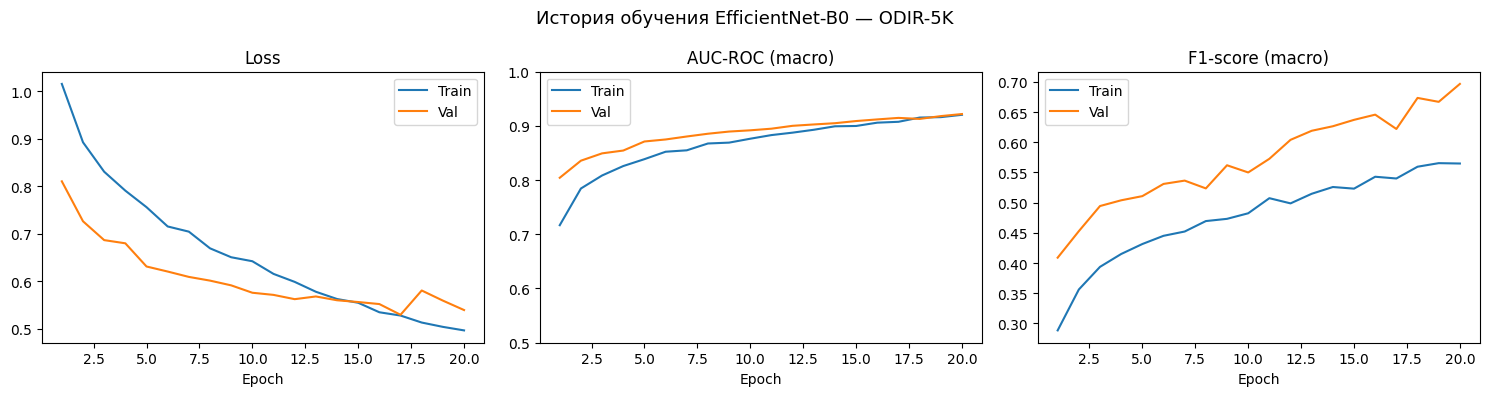

График сохранён


In [19]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('История обучения EfficientNet-B0 — ODIR-5K', fontsize=13)

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(epochs, history['train_auc'], label='Train')
axes[1].plot(epochs, history['val_auc'],   label='Val')
axes[1].set_title('AUC-ROC (macro)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

axes[2].plot(epochs, history['train_f1'], label='Train')
axes[2].plot(epochs, history['val_f1'],   label='Val')
axes[2].set_title('F1-score (macro)')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(MODELS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён')

## Шаг 11 — Сохранение в Google Drive

In [20]:
import shutil

# Создаём папку в Drive
drive_dir = Path('/content/drive/MyDrive/diploma_odir')
drive_dir.mkdir(parents=True, exist_ok=True)

# Копируем модель
shutil.copy(best_model_path, drive_dir / 'best_efficientnet_b0.pth')
shutil.copy(MODELS_DIR / 'training_history.png', drive_dir / 'training_history.png')

# Сохраняем историю и конфиг
with open(drive_dir / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

config = {
    'img_size': IMG_SIZE, 'batch_size': BATCH_SIZE,
    'classes': CLASSES, 'class_names': CLASS_NAMES,
    'pos_weight': pos_weight.tolist(),
    'best_val_auc': best_val_auc, 'best_epoch': best_epoch,
}
with open(drive_dir / 'config.json', 'w', encoding='utf-8') as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

# Сохраняем test.csv тоже (нужен для шага оценки)
shutil.copy(PROCESSED_DIR / 'test.csv', drive_dir / 'test.csv')

print('✅ Всё сохранено в Google Drive → MyDrive/diploma_odir/')
print('Файлы:')
for f in sorted(drive_dir.iterdir()):
    size = f.stat().st_size / 1e6
    print(f'  {f.name}  ({size:.1f} MB)')

✅ Всё сохранено в Google Drive → MyDrive/diploma_odir/
Файлы:
  best_efficientnet_b0.pth  (16.4 MB)
  config.json  (0.0 MB)
  test.csv  (0.2 MB)
  training_history.json  (0.0 MB)
  training_history.png  (0.1 MB)
